# Experimentos aleatorios para revisar rendimiento

## Relación entre twitter 15 y 16

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [55]:
df_train_interactions = pd.read_csv('data_processing/processed_h1/train_interactions.csv')
df_train_interactions.head()
df_test_interactions = pd.read_csv('data_processing/processed_h1/test_interactions.csv')
df_test_interactions.head()

,user_id,item_id,interaction
0,100005598,twitter15_663744139666804736,1
1,100136358,twitter16_732981604826677249,1
2,100332944,twitter15_516435293235183617,1
3,100531988,twitter15_691380348379201536,1
4,1005675566,twitter16_614054616154550273,1


In [59]:
full_df = pd.concat([df_train_interactions, df_test_interactions], ignore_index=True)
full_df.head()
full_df.shape

(63850, 3)

In [60]:
twitter15 = df_train_interactions[full_df['item_id'].str.contains('twitter15')]
twitter16 = df_train_interactions[full_df['item_id'].str.contains('twitter16')]

/var/folders/s6/qscjwrdd52313z5q26c9176m0000gp/T/ipykernel_87468/2047063931.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  twitter15 = df_train_interactions[full_df['item_id'].str.contains('twitter15')]
/var/folders/s6/qscjwrdd52313z5q26c9176m0000gp/T/ipykernel_87468/2047063931.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  twitter16 = df_train_interactions[full_df['item_id'].str.contains('twitter16')]


In [66]:
print(twitter15.shape)
print(twitter16.shape)

print(twitter15['user_id'].nunique())
print(twitter16['user_id'].nunique())

common_users = set(twitter15['user_id']).intersection(set(twitter16['user_id']))
print(len(common_users))

(36032, 4)
(22962, 4)
4835
4738
4717


In [62]:
common_items = set(twitter15['item_id']).intersection(set(twitter16['item_id']))
print(len(common_items))

0


## Time

In [70]:
from datetime import datetime, timezone

TWITTER_EPOCH_MS = 1288834974657  # 2010-11-04 01:42:54.657 UTC

def snowflake_to_datetime(snowflake_id: int) -> datetime:
    """
    Decode a Twitter Snowflake ID (int) to a timezone-aware UTC datetime.
    Works for tweets, users, etc.
    """
    snowflake_id = int(snowflake_id)
    ts_ms = (snowflake_id >> 22) + TWITTER_EPOCH_MS
    return datetime.fromtimestamp(ts_ms / 1000.0, tz=timezone.utc)

# Example:
# tweet_id = 1336401443171983361
# print(snowflake_to_datetime(tweet_id))  # -> 2020-12-08 ... UTC

In [64]:
twitter15['datetime'] = twitter15['item_id'].apply(lambda x: snowflake_to_datetime(int(x.split('_')[1])))
twitter16['datetime'] = twitter16['item_id'].apply(lambda x: snowflake_to_datetime(int(x.split('_')[1])))
twitter15.head()

/var/folders/s6/qscjwrdd52313z5q26c9176m0000gp/T/ipykernel_87468/4164124674.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  twitter15['datetime'] = twitter15['item_id'].apply(lambda x: snowflake_to_datetime(int(x.split('_')[1])))
/var/folders/s6/qscjwrdd52313z5q26c9176m0000gp/T/ipykernel_87468/4164124674.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  twitter16['datetime'] = twitter16['item_id'].apply(lambda x: snowflake_to_datetime(int(x.split('_')[1])))


,user_id,item_id,interaction,datetime
0,100005598,twitter15_688751183645782016,1,2016-01-17 15:54:13.216000+00:00
1,100005598,twitter15_504244627680272384,1,2014-08-26 12:31:02.308000+00:00
2,100005598,twitter15_499368931367608320,1,2014-08-13 01:36:45.721000+00:00
6,100005598,twitter15_688502260779843587,1,2016-01-16 23:25:05.380000+00:00
8,100005598,twitter15_691027026552229888,1,2016-01-23 22:37:36.448000+00:00


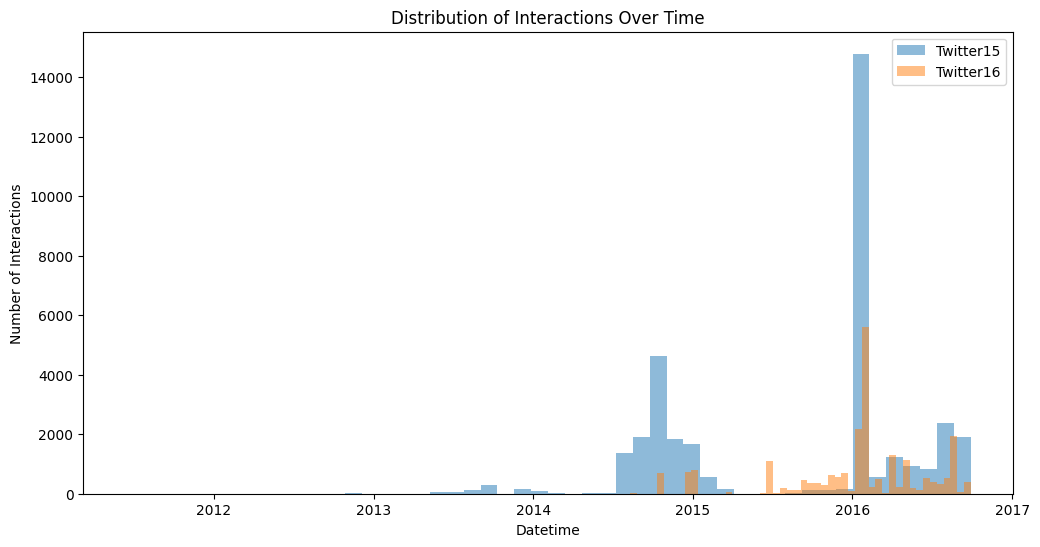

In [65]:
fig = plt.figure(figsize=(12, 6))
plt.hist(twitter15['datetime'], bins=50, alpha=0.5, label='Twitter15')
plt.hist(twitter16['datetime'], bins=50, alpha=0.5, label='Twitter16')
plt.xlabel('Datetime')
plt.ylabel('Number of Interactions')
plt.title('Distribution of Interactions Over Time')
plt.legend()
plt.show()

In [70]:
print(snowflake_to_datetime(780882510645370880))

2016-09-27 21:31:13.290000+00:00


In [88]:
df_Test = pd.read_csv('data_processing/twitter15/label.txt', header=None)
df_Test.shape

(1490, 1)

In [ ]:
df_test = pd.read_csv('data_processing/processed_h1/test_interactions.csv')
df_test.shape

(4856, 3)

## Probar dataset desde 0 a ver que onda el split.

In [ ]:
import os
import ast
import re
import pandas as pd
from collections import Counter

BASE = '../datasets/new_datasets/twitter15'
TREE_DIR = os.path.join(BASE, 'tree')
LABEL_PATH = os.path.join(BASE, 'label.txt')

rows = []
unique_users = set()
source_ids = []
posts_in_event_list = []

c = 0
k = 0
q = 0

posts_in_event = set()

for root, dirs, files in os.walk(TREE_DIR):
    print('root:', root)
    for fname in files:

        c += 1
        q -= 1


        source_tree_id = os.path.splitext(fname)[0]
        source_ids.append(source_tree_id)

        fpath = os.path.join(root, fname)

        with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
            # DO NOT skip the first line; the first line is ROOT -> (real root)
            for line in f:

                k += 1
                q += 1

                line = line.strip()
                if not line or '->' not in line:
                    continue

                left_str, right_str = line.split('->', 1)
                parent = ast.literal_eval(left_str)
                child  = ast.literal_eval(right_str)

                p_uid, p_tid, p_delay = parent
                c_uid, c_tid, c_delay = child

                if p_uid != 'ROOT':
                    unique_users.add(str(p_uid))
                if c_uid != 'ROOT':
                    unique_users.add(str(c_uid))

                is_new_post = (p_tid != c_tid)

                posts_in_event.add((str(c_uid), str(c_tid)))

                rows.append({
                    'source_tree_id': source_tree_id,
                    'is_new_post': is_new_post,
                    'parent_user_id': str(p_uid),
                    'parent_tweet_id': str(p_tid),
                    'parent_delay_min': float(p_delay),
                    'child_user_id': str(c_uid),
                    'child_tweet_id': str(c_tid),
                    'child_delay_min': float(c_delay),
                })

            posts_in_event_list.append(len(posts_in_event))

df15 = pd.DataFrame(rows, columns=[
    'source_tree_id', 'is_new_post',
    'parent_user_id', 'parent_tweet_id', 'parent_delay_min',
    'child_user_id',  'child_tweet_id',  'child_delay_min'
])

print('C:', c)
print('K:', k)
print('Q:', q)

print('Total number of rows/edges:', len(df15))

# Enforce string for ids
for col in ['source_tree_id', 'parent_user_id', 'parent_tweet_id', 'child_user_id', 'child_tweet_id']:
    df15[col] = df15[col].astype('string')


label_counts = Counter()
label_of = {}

label_map = {
    'non-rumor': 'NR',
    'false': 'FR',
    'true': 'TR',
    'unverified': 'UR',
}


label_counts = Counter()
if os.path.exists(LABEL_PATH):
    with open(LABEL_PATH, 'r', encoding='utf-8', errors='ignore') as f:
        for raw in f:
            s = raw.strip()
            if not s:
                continue
            # expecting "label:tweetid"
            try:
                label_str, sid = s.split(':', 1)
            except ValueError:
                # tolerate malformed lines
                continue
            label_str = label_str.strip().lower()
            sid = sid.strip()

            short = label_map.get(label_str)
            if not short:
                # unknown label -> skip
                continue

            label_of[sid] = short
            label_counts[short] += 1

    # Sanity checks: one label per source tree id
    files_set = set(source_ids)
    labeled_set = set(label_of.keys())

    missing_labels = files_set - labeled_set
    extra_labels = labeled_set - files_set

    print("\n=== Label stats ===")
    print(f"Label lines: {len(label_of)} (should match # source tweets)")

    if missing_labels:
        print(f"WARNING: {len(missing_labels)} trees missing labels (e.g., {next(iter(missing_labels))})")
    if extra_labels:
        print(f"WARNING: {len(extra_labels)} labels without a tree file (e.g., {next(iter(extra_labels))})")

    # Print in canonical order matching the paper table
    print("\nCounts by class:")
    print(f"# of non-rumors (NR):     {label_counts.get('NR', 0)}")
    print(f"# of false-rumors (FR):   {label_counts.get('FR', 0)}")
    print(f"# of true-rumors (TR):    {label_counts.get('TR', 0)}")
    print(f"# of unverified (UR):     {label_counts.get('UR', 0)}")
else:
    print("\n(label.txt not found — skipping label counts)")

root: ../datasets/new_datasets/twitter15/tree
C: 1490
K: 607289
Q: 605799
Total number of rows/edges: 607289

=== Label stats ===
Label lines: 1490 (should match # source tweets)

Counts by class:
# of non-rumors (NR):     374
# of false-rumors (FR):   370
# of true-rumors (TR):    372
# of unverified (UR):     374


In [72]:
df15.head()

,source_tree_id,is_new_post,parent_user_id,parent_tweet_id,parent_delay_min,child_user_id,child_tweet_id,child_delay_min
0,724703995147751424,True,ROOT,ROOT,0.0,15754281,724703995147751424,0.00
1,724703995147751424,True,15754281,724703995147751424,0.0,27264308,724704170205278208,0.70
2,724703995147751424,True,15754281,724703995147751424,0.0,2411458885,724704234915155968,0.95
3,724703995147751424,True,15754281,724703995147751424,0.0,2748549301,724704415731470336,1.67
4,724703995147751424,True,15754281,724703995147751424,0.0,23147878,724704473172586496,1.90


In [73]:
df15['parent_datetime'] = df15['parent_tweet_id'].apply(lambda x: snowflake_to_datetime(int(x)) if x != 'ROOT' else None)
df15['child_datetime'] = df15['child_tweet_id'].apply(lambda x: snowflake_to_datetime(int(x)))

In [74]:
df15['veracity'] = df15['source_tree_id'].map(label_of)
df15.head()

,source_tree_id,is_new_post,parent_user_id,parent_tweet_id,parent_delay_min,child_user_id,child_tweet_id,child_delay_min,parent_datetime,child_datetime,veracity
0,724703995147751424,True,ROOT,ROOT,0.0,15754281,724703995147751424,0.00,NaT,2016-04-25 20:57:51.449000+00:00,UR
1,724703995147751424,True,15754281,724703995147751424,0.0,27264308,724704170205278208,0.70,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:58:33.186000+00:00,UR
2,724703995147751424,True,15754281,724703995147751424,0.0,2411458885,724704234915155968,0.95,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:58:48.614000+00:00,UR
3,724703995147751424,True,15754281,724703995147751424,0.0,2748549301,724704415731470336,1.67,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:59:31.724000+00:00,UR
4,724703995147751424,True,15754281,724703995147751424,0.0,23147878,724704473172586496,1.90,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:59:45.419000+00:00,UR


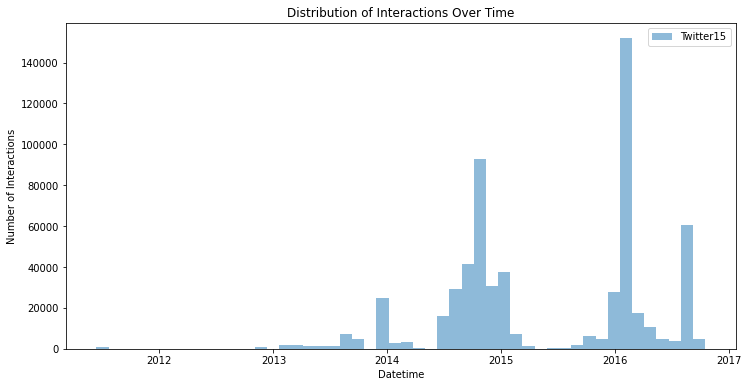

In [77]:
a = df15[df15['parent_tweet_id'] != 'ROOT']
fig = plt.figure(figsize=(12, 6))
plt.hist(a['parent_datetime'], bins=50, alpha=0.5, label='Twitter15')
plt.xlabel('Datetime')
plt.ylabel('Number of Interactions')
plt.title('Distribution of Interactions Over Time')
plt.legend()
plt.show()

Esto es con el Twitter16

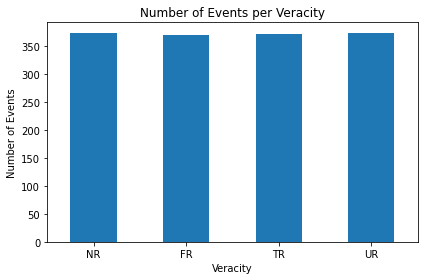

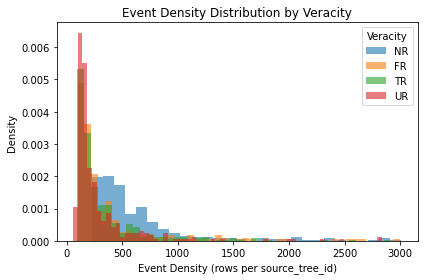

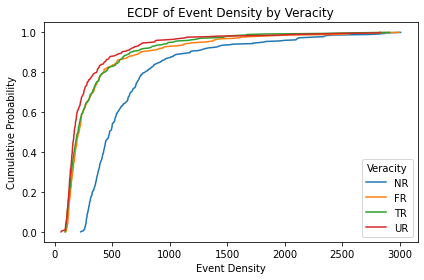

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 0) Basic sanity checks ---
required_cols = {
    "source_tree_id","veracity","source_tree_id","is_new_post","parent_user_id",
    "parent_tweet_id","parent_delay_min","child_user_id","child_tweet_id",
    "child_delay_min","parent_datetime","child_datetime"
}
missing = [c for c in ["source_tree_id","veracity"] if c not in df15.columns]
if missing:
    raise ValueError(f"Your df is missing required columns: {missing}")

# --- 1) Build one row per event with density and a single veracity label ---
# density = number of rows for that event
density = df15.groupby("source_tree_id").size().rename("density")

# veracity per event = mode (most common label). If ties, take the first mode.
def mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan

veracity_per_event = (
    df15.groupby("source_tree_id")["veracity"]
      .agg(mode_or_first)
      .rename("veracity")
)

events = (
    pd.concat([density, veracity_per_event], axis=1)
      .reset_index()  # has: source_tree_id, density, veracity
)

# --- 2) Optional: warn if an event mixes labels ---
# (Useful to know if veracity isn't constant inside an event.)
mixed_mask = (
    df15.groupby("source_tree_id")["veracity"]
      .nunique()
      .rename("n_veracity")
      .gt(1)
)
n_mixed = mixed_mask.sum()
if n_mixed:
    print(f"⚠️ {n_mixed} events contain mixed veracity labels. "
          f"Plotting uses the mode per event.")

# --- 3) Plot: number of events per veracity (occurrence) ---
order = ["NR","FR","TR","UR"]  # adjust if you use different/extra labels
counts = (
    events["veracity"]
    .value_counts()
    .reindex(order)
    .fillna(0)
    .astype(int)
)

plt.figure()
counts.plot(kind="bar")
plt.title("Number of Events per Veracity")
plt.xlabel("Veracity")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 4) Plot: density distribution per veracity (overlaid histograms) ---
plt.figure()
labels_present = [v for v in order if v in events["veracity"].unique()]
for v in labels_present:
    subset = events.loc[events["veracity"] == v, "density"]
    plt.hist(subset, bins="auto", alpha=0.6, density=True, label=v)
plt.title("Event Density Distribution by Veracity")
plt.xlabel("Event Density (rows per source_tree_id)")
plt.ylabel("Density")
plt.legend(title="Veracity")
plt.tight_layout()
plt.show()

# --- 5) (Optional) ECDF comparison (less bin-sensitive than hist) ---
def ecdf(x):
    x = np.sort(np.asarray(x))
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

plt.figure()
for v in labels_present:
    x, y = ecdf(events.loc[events["veracity"] == v, "density"])
    plt.plot(x, y, marker="", linestyle="-", label=v)
plt.title("ECDF of Event Density by Veracity")
plt.xlabel("Event Density")
plt.ylabel("Cumulative Probability")
plt.legend(title="Veracity")
plt.tight_layout()
plt.show()


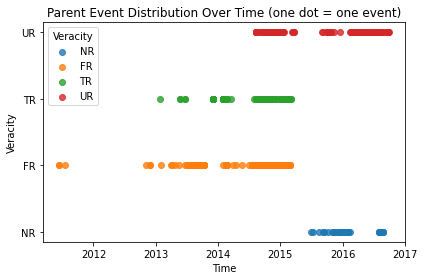

"\n\n    'non-rumor': 'NR',\n    'false': 'FR',\n    'true': 'TR',\n    'unverified': 'UR',\n\n"

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Ensure datetime
df15["parent_datetime"] = pd.to_datetime(df15["parent_datetime"], errors="coerce")

# 2) One row per event: event_time = earliest parent_datetime; veracity = mode
events = (
    df15.groupby("source_tree_id")
        .agg(
            event_time=("parent_datetime", "min"),
            veracity=("veracity", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan),
        )
        .dropna(subset=["event_time", "veracity"])
        .reset_index()
)

# 3) Put veracity on a tidy y-axis (one band per label)
order = ["NR", "FR", "TR", "UR"]
present = [v for v in order if v in events["veracity"].unique()]
if not present:  # fallback to whatever is present
    present = list(pd.Series(events["veracity"].unique()).dropna())

cat = pd.Categorical(events["veracity"], categories=present, ordered=True)
ypos = cat.codes  # 0..n-1

# 4) Plot: distribution over time, colored by veracity
plt.figure()
for v in present:
    m = events["veracity"] == v
    plt.scatter(events.loc[m, "event_time"], ypos[m], label=v, alpha=0.8)

plt.yticks(range(len(present)), present)
plt.xlabel("Time")
plt.ylabel("Veracity")
plt.title("Parent Event Distribution Over Time (one dot = one event)")
plt.legend(title="Veracity")
plt.tight_layout()
plt.show()

'''

    'non-rumor': 'NR',
    'false': 'FR',
    'true': 'TR',
    'unverified': 'UR',

'''

Overall summary (medians):
 median_posts  median_active_days  median_posts_per_active_day  median_burstiness
          1.0                 1.0                          1.0           0.171573

Top 10 users by posts:
          n_posts  active_days    span_days  posts_per_active_day  burstiness
user_id                                                                      
5402612     32031           25   673.822794           1281.240000    0.982300
30313925    26329           22   217.992041           1196.772727    0.985689
2557521     24856            6   207.516022           4142.666667    0.987068
428333      18688           17   727.338347           1099.294118    0.978802
14075928    16266           13  1364.650980           1251.230769    0.978157
759251      12906           20   915.275456            645.300000    0.965918
2883841     11572           17   865.689861            680.705882    0.959324
1367531      8908           22  1188.846218            404.909091    0.945563
23679

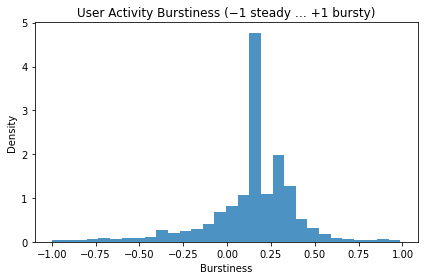

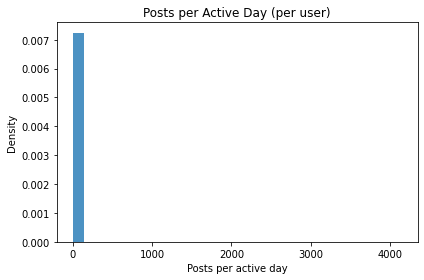

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Build a unified (user, datetime) activity table from parents + children ---
u_parent = df15[["parent_user_id", "parent_datetime"]].rename(
    columns={"parent_user_id": "user_id", "parent_datetime": "dt"}
)
u_child = df15[["child_user_id", "child_datetime"]].rename(
    columns={"child_user_id": "user_id", "child_datetime": "dt"}
)

acts = pd.concat([u_parent, u_child], ignore_index=True)
acts["dt"] = pd.to_datetime(acts["dt"], errors="coerce")
acts = acts.dropna(subset=["user_id", "dt"]).sort_values(["user_id", "dt"])

# --- 2) Per-user stats ---
grp = acts.groupby("user_id", sort=False)
n_posts = grp.size().rename("n_posts")
active_days = grp["dt"].apply(lambda s: s.dt.floor("D").nunique()).rename("active_days")
span_days = (grp["dt"].max() - grp["dt"].min()).dt.total_seconds().div(86400).rename("span_days")

# Inter-event times (seconds) per user
inter = acts.groupby("user_id")["dt"].diff().dt.total_seconds()

def burstiness_metric(x):
    x = pd.Series(x).dropna()
    if len(x) < 2:  # need variability
        return np.nan
    mu, sigma = x.mean(), x.std(ddof=1)
    if mu + sigma == 0:
        return np.nan
    return (sigma - mu) / (sigma + mu)  # -1 ≈ regular; +1 ≈ bursty

burstiness = inter.groupby(acts["user_id"]).apply(burstiness_metric).rename("burstiness")

posts_per_active_day = (n_posts / active_days.replace({0: np.nan})).rename("posts_per_active_day")

user_stats = (
    pd.concat([n_posts, active_days, span_days, posts_per_active_day, burstiness], axis=1)
      .sort_values("n_posts", ascending=False)
)

# --- 3) Quick summary table (you can display/print as you prefer) ---
summary_row = pd.DataFrame({
    "median_posts": [user_stats["n_posts"].median()],
    "median_active_days": [user_stats["active_days"].median()],
    "median_posts_per_active_day": [user_stats["posts_per_active_day"].median()],
    "median_burstiness": [user_stats["burstiness"].median()],
})
print("Overall summary (medians):")
print(summary_row.to_string(index=False))
print("\nTop 10 users by posts:")
print(user_stats.head(10).to_string())

# --- 4) Plots: (a) burstiness distribution, (b) posts per active day distribution ---

# (a) Burstiness histogram: -1 steady ... +1 bursty
plt.figure()
valid_b = user_stats["burstiness"].dropna()
plt.hist(valid_b, bins=30, density=True, alpha=0.8)
plt.title("User Activity Burstiness (−1 steady … +1 bursty)")
plt.xlabel("Burstiness")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# (b) Posts per active day (how concentrated daily effort is)
plt.figure()
ppd = user_stats["posts_per_active_day"].dropna()
plt.hist(ppd, bins=30, density=True, alpha=0.8)
plt.title("Posts per Active Day (per user)")
plt.xlabel("Posts per active day")
plt.ylabel("Density")
plt.tight_layout()
plt.show()
